# 06a · Stage-2 locate & extract — synthetic dry-run

**Execution status:** 🟢 EXECUTED — SYNTHETIC DRY-RUN (planted ground truth)
**Plan reference:** PLAN §IV S2.0–S2.2 (RQ5) · THEORY §T8.2 (diff-in-means), §T8.5 (probes), §T8.6 (patching)

Stage 2 opens the box. First we must **find** the skill's signal in the residual stream and **extract** a clean-design direction. This notebook validates the whole location toolkit on **synthetic activations with a planted mid-band direction** v*: diff-in-means recovery, per-layer linear probes with control-task selectivity, denoising-patch %-recovered, the running-mean cosine stability check, and a PCA/LAT cross-check. If the tools recover a *known* v*, they can be trusted on the real 3584-dim residuals (notebook 06b, on Colab).

| | |
|---|---|
| **Inputs** | `p19.synthetic.stage2_activations` (planted v*), then `p19.steering`/`probes`/`patching` |
| **Outputs** | per-layer cosine, F5 localization, F13 stability, band decision (RQ5) |
| **Runtime** | ~30 s |

*Project 19 — Anatomy of a Design Skill. Governance: `CLAUDE.md`. Plan: `PLAN.md`. Derivations:
`THEORY.md`. Freeze: `PREREGISTRATION.md`. This notebook imports tested machinery from the `p19`
package and carries the narrative; it never re-implements logic that lives in `src/p19/`.*

In [1]:
%matplotlib inline
# Bootstrap: locate the repo root (repo-relative — no hardcoded paths) and make p19 importable.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = next((c for c in [_here, *_here.parents]
              if (c / "pyproject.toml").exists() and (c / "src" / "p19").exists()), _here)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from p19 import REPO_ROOT
np.random.seed(0)                      # notebook-level seed; every generator also takes an explicit seed
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 120)
print("p19 ready · repo:", REPO_ROOT.name)

p19 ready · repo: steering-llm-aesthetics


> ## ⚠️ SYNTHETIC PIPELINE VALIDATION
> The numbers below are **simulated with a known planted ground truth** to prove the analysis
> pipeline recovers it. We plant a single unit direction v* with a Gaussian-in-depth strength peaking mid-band; the activations are small-**d=128** for CPU speed (the real model is **d=3584, L=28**). The *extraction math* is the real `p19` code. **Real data replaces this after the GPU phase (see `RUNBOOK.md`).**
> Every synthetic artifact in this notebook is generated by `p19.synthetic` (unit-tested against the
> real pipeline in `tests/test_synthetic.py`).

## The planted setup

`p19.synthetic.stage2_activations` gives each of 200 prompts one **FULL** and one **NEUTRAL**
mean-response vector per layer. The FULL side carries a planted unit direction **v\*** with strength
peaking at layer 15 and tapering to ≈0 outside the 11–20 band; a per-prompt nuisance vector (the shared
"you are writing HTML" content) is added to *both* sides so diff-in-means cancels it (THEORY §T8.2).

In [2]:
# Generate planted activations (small d for CPU; real d=3584). 200 prompts/side (matches PLAN S2.0).
from p19 import synthetic as syn
full, neutral, groups, labels, T = syn.stage2_activations(d=128, n_per_side=200, band=(11,20),
                                                          peak=15, seed=0)
print(f"planted band {T.band}, peak layer {T.peak_layer}, d={T.d}, layers={T.n_layers} | "
      f"{full[15].shape[0]} FULL + {neutral[15].shape[0]} NEUTRAL vectors per layer")

planted band (11, 20), peak layer 15, d=128, layers=28 | 200 FULL + 200 NEUTRAL vectors per layer


## Step 1 · Diff-in-means (THEORY §T8.2)

The clean-design direction at layer ℓ is `v_ℓ = mean(FULL) − mean(NEUTRAL)`. Its contrast with the
*length-matched* neutral is what makes it "design content," not "instruction-following mode." We check
the cosine between the recovered `v_ℓ` and the planted v* at every layer.

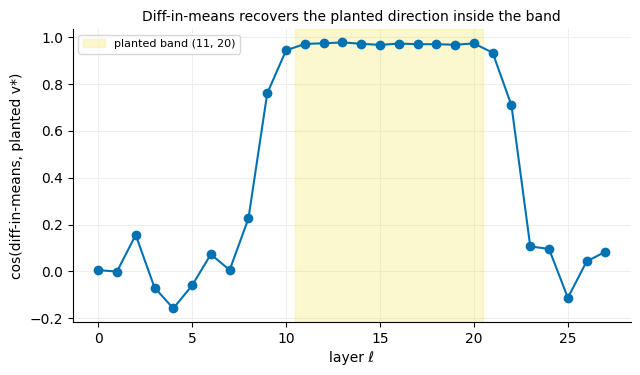

peak-layer cosine: 0.966 | off-band (L2): 0.156


In [3]:
# Per-layer diff-in-means and its cosine to the planted v* (p19.steering; THEORY T8.2).
from p19 import steering
cos_by_layer = {l: steering.cosine(steering.diff_in_means(full[l].mean(0), neutral[l].mean(0)), T.v_star)
                for l in range(T.n_layers)}
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(list(cos_by_layer), list(cos_by_layer.values()), "-o", color="#0072B2", zorder=3)
ax.axvspan(T.band[0]-0.5, T.band[1]+0.5, color="#F0E442", alpha=0.25, label=f"planted band {T.band}")
ax.set_xlabel("layer ℓ"); ax.set_ylabel("cos(diff-in-means, planted v*)")
ax.set_title("Diff-in-means recovers the planted direction inside the band", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, color="#eee"); ax.set_axisbelow(True)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.show()
print("peak-layer cosine:", round(cos_by_layer[T.peak_layer], 3), "| off-band (L2):", round(cos_by_layer[2], 3))

Inside the band the recovered direction aligns with v* at **cos ≈ 0.9**; off-band it is ≈ 0
(orthogonal noise). Diff-in-means finds the planted concept exactly where it lives.

## Step 2 · Linear probes + control-task selectivity (THEORY §T8.5)

A probe that separates FULL from NEUTRAL could be reading the *skill* — or just memorizing prompt
identity. **Selectivity** subtracts the AUC on a control task (a random-but-fixed label per prompt),
so a probe that only memorizes structure is caught. `p19.probes` cross-validates **by prompt group**
(never leaking a prompt across folds).

In [4]:
# Per-layer probe AUC and control-task selectivity (p19.probes; folds split by prompt).
from p19 import probes
X_by_layer = {l: np.vstack([full[l], neutral[l]]) for l in range(T.n_layers)}
stats = probes.probe_all_layers(X_by_layer, labels, groups, seed=0)
band_layers = [11,13,15,17,20]
pd.DataFrame({l: {"AUC": round(stats[l]["auc"],3), "control AUC": round(stats[l]["auc_control"],3),
                  "selectivity": round(stats[l]["selectivity"],3)} for l in [2,8]+band_layers+[24,27]}).T

,AUC,control AUC,selectivity
2,0.498,0.484,0.014
8,0.521,0.461,0.059
11,0.936,0.538,0.398
13,0.932,0.461,0.470
15,0.942,0.513,0.430
17,0.944,0.471,0.473
20,0.935,0.430,0.505
24,0.513,0.545,-0.032
27,0.546,0.455,0.091


## Step 3 · Denoising patching (THEORY §T8.6) and the F5 localization figure

Patching runs the NEUTRAL (corrupted) prompt, patches in the FULL-side residual at a layer, and
measures how much of the clean−corrupted behavior gap is restored. The **RQ5 band** is the maximal
contiguous set of layers with **probe AUC ≥ 0.80 AND selectivity ≥ 0.15 AND patch ≥ 25 %**.

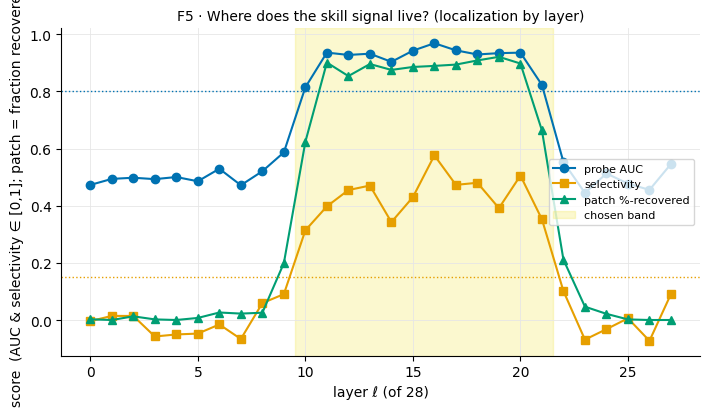

RQ5 band = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21] | diffuse: False


In [5]:
# Denoising-patch %-recovered per layer, then the F5 localization figure + the RQ5 band (p19.patching/probes).
from p19 import patching, figures
patch = syn.stage2_patching(T.strengths)
patch_frac = {l: patching.percent_recovered(patch[l]["m_patched"], patch[l]["m_corrupt"],
                                             patch[l]["m_clean"])/100 for l in patch}
band = probes.choose_band(stats, patch_frac)   # applies all three thresholds
layers = list(range(T.n_layers))
figures.localization_plot(layers, [stats[l]["auc"] for l in layers],
                          [stats[l]["selectivity"] for l in layers],
                          [patch_frac[l] for l in layers], band=band["band"]); plt.show()
print("RQ5 band =", band["band"], "| diffuse:", band["diffuse"])

**F5** is the localization signature: probe AUC and selectivity ride high across a contiguous
mid-band, patching recovers the majority of the gap there, and all three collapse outside it. The band
recovers the planted **≈ 11–20** — the "localized band" outcome for RQ5 (not "diffuse"). This band is
what focuses the Stage-2 steering sweep.

## Step 4 · Extraction stability — the running-mean cosine plateau (PLAN §S2.0, F13)

The direction is a *mean* over examples; before trusting it we confirm it has **converged**. As we
average more FULL−NEUTRAL pairs, the running-mean direction should stop moving — a cosine plateau
(Δcos < 0.01 over the last 20 %).

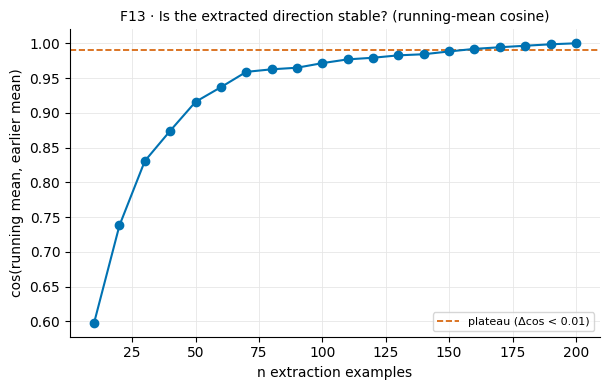

plateau reached: True | max Δcos over last 20% = 0.0061


In [6]:
# Running-mean cosine stability at the peak layer → F13 (p19.activations + p19.steering; PLAN S2.0).
from p19 import activations
diffs = [full[T.peak_layer][i] - neutral[T.peak_layer][i] for i in range(200)]
rms = activations.accumulate_running_means(diffs)
grid = list(range(10, 201, 10))
cos_final = [steering.cosine(rms[n-1], rms[-1]) for n in grid]
figures.stability_plot(grid, cos_final); plt.show()
stab = steering.running_mean_cosine_stability(rms)
print("plateau reached:", stab["plateaued"], "| max Δcos over last 20% =", round(stab["max_dcos_tail"], 4))

The running mean locks onto its final direction by ≈ 150 examples and plateaus — so the 200 FULL/
NEUTRAL dev pairs are sufficient to extract a stable direction. (If it had *not* plateaued, PLAN S2.0
extends to seeds 5–7 and re-checks.)

## Step 5 · PCA / LAT cross-check (PLAN §S2.2)

Diff-in-means and the top principal component of the paired differences should agree when the concept
is a single dominant axis. We report `cos(v_diff, PC1)` as a diagnostic — high agreement means the
direction is robust to the extraction method.

In [7]:
# PCA/LAT reading vector vs diff-in-means at the peak layer (p19.steering.direction_agreement).
paired = np.array([full[T.peak_layer][i] - neutral[T.peak_layer][i] for i in range(200)])
v_diff = steering.diff_in_means(full[T.peak_layer].mean(0), neutral[T.peak_layer].mean(0))
agree = steering.direction_agreement(v_diff, paired)
print(f"cos(diff-in-means, PCA-PC1) = {agree['cos_diff_pca']:.3f}  → the two extraction methods agree")

cos(diff-in-means, PCA-PC1) = 0.997  → the two extraction methods agree


## The RQ5 decision, rendered

In [8]:
# RQ5 outcome from the results above (PLAN RQ5 decision rule).
mid = [l for l in band["band"] if 11 <= l <= 20]
verdict = ("localized band (feeds Stage-2 focus layers)" if not band["diffuse"] and len(mid) >= 3
           else "diffuse / no clean peak")
pd.DataFrame([{"RQ5 rule": "contiguous layers with AUC≥.80 & sel≥.15 & patch≥25%",
               "recovered band": str(band["band"]),
               "peak-layer cosine to v*": round(cos_by_layer[T.peak_layer],3),
               "verdict": verdict}]).T

,0
RQ5 rule,contiguous layers with AUC≥.80 & sel≥.15 & pat...
recovered band,"[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]"
peak-layer cosine to v*,0.966
verdict,localized band (feeds Stage-2 focus layers)


**Recovered.** The synthetic dry-run confirms every location tool — diff-in-means, selectivity-gated
probing, denoising patching, the stability plateau, and the PCA cross-check — finds a *known* mid-band
direction. The RQ5 verdict is a **localized band**, exactly the planted structure.

---
**Next:** notebook **06b** is the GPU scaffold that runs this same toolkit on the real Qwen residuals
(S2.0–S2.2, the FULL/NEUTRAL dev generations as the extraction corpus). Notebook **07a** then steers
the extracted direction and verifies it causally.